# Modular pipeline: specimen placement → ice → tilt-coverage padding → per-tilt scattering → optics → detector

The other tilt-series notebook (`create_tilt_series/`) goes through `TiltSeriesGenerator`:
one class that blends ice into a pre-assembled specimen volume, pads it in XY for the
requested tilt range, and drives `IterativeScattering` → `Aberration` → `Detector` once
per tilt angle from `generate_tilt_series()`.

This notebook builds the **same physical pipeline by hand**, one stage per section,
calling each module directly instead of going through `TiltSeriesGenerator`. Specimen
placement itself is already exposed as a standalone piece -- `CryoETSpecimenGenerator` --
and is used identically in both notebooks; the "modular" part here is what
`TiltSeriesGenerator` does internally with that assembled volume (see
`create_particle_stack_modular/` for the equivalent breakdown of `ImageGenerator`, the
single-particle counterpart).

Pipeline (mirrors `TiltSeriesGenerator.__init__`/`generate_tilt_series` in
`imagegenerator/_tiltseries.py`, stage for stage):

```
protein/membrane specs
  └─ placed specimen volume           (specter.specimen.CryoETSpecimenGenerator)
      └─ + amorphous ice               (specter.ice: resolve_icemaker / blend_ice_into_volume)
          └─ padded for tilt coverage   (TiltSeriesGenerator's own geometry helpers)
              └─ per tilt angle:
                  ├─ affine pose                    (specter.rotations)
                  ├─ rotate + multislice, fused     (specter.scattering.IterativeScattering)
                  ├─ aberrated exit wave            (specter.aberrations.Aberration)
                  └─ detector image                 (specter.microscope.Detector)
```

All parameters live in
[`tilt_series_generator_modular.toml`](./tilt_series_generator_modular.toml), loaded below
via `load_config` -- same TOML-driven convention as the other demo notebooks. Edit that
file, not this notebook, to change the specimen composition, box size, tilt range,
defocus, etc.


In [1]:
import logging
import time

import matplotlib.pyplot as plt
import roma
import torch

import specter
from specter import rotations
from specter.config import load_config, TiltSeriesConfig
from specter.plots import plot_particle_stack
from specter.specimen.cryoet import CryoETSpecimenGenerator
from specter.specimen.cytosolic_filler import build_filler_protein_specs
from specter.ice import resolve_icemaker, blend_ice_into_volume
from specter.scattering import IterativeScattering
from specter.aberrations import Aberration, defocus_midplane_shift
from specter.microscope import Detector
from specter.imagegenerator import TiltSeriesGenerator

%load_ext autoreload
%autoreload 2

In [2]:
config = load_config("tilt_series_generator_modular.toml", TiltSeriesConfig)

In [3]:
specter.set_verbosity(logging.INFO)
device = config.device
device

'cuda:2'

## 1. Specimen placement

`CryoETSpecimenGenerator` runs `polnet`'s non-overlapping, occupancy-driven packing of
proteins + membranes, then renders the real high-resolution scattering potential
directly (one atomic potential per protein species, an analytic bilayer per membrane).
This step is identical to what `TiltSeriesGenerator`'s caller does in `create_tilt_series/`
-- it's already a standalone, reusable object, no changes needed here.


In [4]:
protein_specs = list(config.protein_specs)
if config.filler_occupancy is not None:
    protein_specs += build_filler_protein_specs(total_occupancy=config.filler_occupancy)

gen = CryoETSpecimenGenerator(
    protein_specs=protein_specs,
    membrane_specs=config.membrane_specs,
    target_shape=tuple(config.target_shape),
    target_v_size=config.target_v_size,
    low_res_v_size=config.low_res_v_size,
    pdb_cache_dir=config.pdb_savefolder,
    membrane_potential_scale=config.membrane_potential_scale,
    seed=config.seed,
)

t0 = time.time()
volume = gen.generate()
print(f"generated in {time.time() - t0:.1f}s")
print(
    "shape:",
    tuple(volume.shape),
    "nonzero voxels:",
    int((volume > 0).sum()),
    "max:",
    float(volume.max()),
)

[cryoet] low-res placement: (103, 103, 52) voxels @ 10.0 A/vx, 6 protein species, 1 membrane spec(s)


[05:51:44] INFO: Inserted 1 membranes of type 'sphere' with occupancy 8.7329 %.


[cryoet]   7VD8: 36713 atoms, low-res placeholder built in 5.7s
[cryoet]   6QZP: 219463 atoms, low-res placeholder built in 12.0s
[cryoet]   7B75: 39122 atoms, low-res placeholder built in 4.4s
[cryoet]   6N4V: 236760 atoms, low-res placeholder built in 12.2s
[cryoet]   6DRV: 32888 atoms, low-res placeholder built in 3.7s
[cryoet]   1FA2: 16288 atoms, low-res placeholder built in 3.3s
[cryoet] membrane placement + protein SVOL builds done in 41.4s (ran concurrently)
[cryoet] running polnet protein packing...


[05:52:24] INFO: No 6N4V proteins generated.


[cryoet] polnet protein packing done in 1.1s
[cryoet] 8 protein instance(s) placed
[cryoet]   chain sizes (SAWLC): 7VD8: {2: 1}; 6QZP: {1: 1}; 7B75: {2: 1}; 6DRV: {1: 1}; 1FA2: {2: 1}
[cryoet] 1 membrane instance(s) fitted
[cryoet] high-res assembly: (256, 512, 512) voxels @ 2 A/vx
[cryoet]   1FA2: high-res potential (72^3 @ 2 A/vx) built in 0.0s
[cryoet]   6DRV: high-res potential (96^3 @ 2 A/vx) built in 0.0s
[cryoet]   6QZP: high-res potential (166^3 @ 2 A/vx) built in 1.9s
[cryoet]   7B75: high-res potential (136^3 @ 2 A/vx) built in 0.9s
[cryoet]   7VD8: high-res potential (72^3 @ 2 A/vx) built in 0.1s
[cryoet] organic-matter potential reference: 16.2 (mean over-half-max value, averaged across 5 protein species -- used to calibrate membrane voxel values)
[cryoet] stamped 8 protein instance(s) in 0.7s
[cryoet] stamped 1 membrane instance(s) in 7.5s
generated in 53.6s
shape: (256, 512, 512) nonzero voxels: 12556327 max: 28.499773025512695


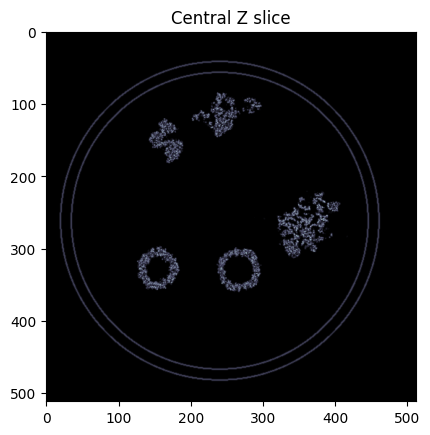

In [5]:
plt.imshow(volume[volume.shape[0] // 2], cmap="bone")
plt.title("Central Z slice")
plt.show()

## 2. Amorphous ice solvation

Ice is added only where the structure itself has little density. `resolve_icemaker`
turns the `ice_model` string into a concrete `IceBank`/`RandomIcemaker` -- the same
helper `TiltSeriesGenerator.__init__` calls internally on its `vol` argument, before any
of its own tilt-coverage padding -- and `blend_ice_into_volume` masks and adds the ice.
Both live in `specter.ice` and have no dependency on `TiltSeriesGenerator` at all, so
they're called here exactly as-is, directly on the assembled `volume` (reshaped to the
`(1, Z, Y, X)` shape the tilt-series pipeline expects).

`ice_model="gd"` samples from the bundled `IceBank` cache (`ice-data/ice_cache`) --
physically relaxed, the realistic option; `"random"` is an instant, cheap placeholder
with no real structure, useful only for quick smoke tests.


In [6]:
vol = volume.unsqueeze(0)  # (1, Z, Y, X), TiltSeriesGenerator's expected shape

ice_model = None if config.ice_model == "none" else config.ice_model

icemaker = resolve_icemaker(
    ice_model,
    config.target_v_size,
    nxy=vol.shape[-1],
    nz=vol.shape[-3],
    ice_cache_dir=config.ice_cache_dir,
)

if icemaker is not None:
    with torch.no_grad():
        vol = blend_ice_into_volume(
            vol, icemaker, config.target_v_size, relax_steps=config.ice_relax_steps
        )

vol.shape

Placing ice tiles:   0%|          | 0/32 [00:00<?, ?it/s]

torch.Size([1, 256, 512, 512])

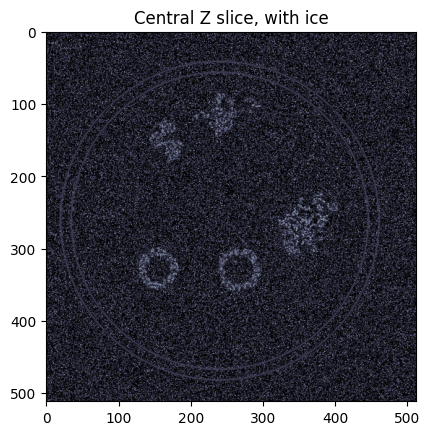

In [7]:
plt.imshow(vol[0, vol.shape[1] // 2].cpu(), cmap="bone")
plt.title("Central Z slice, with ice")
plt.show()

## 3. Padding for tilt coverage

At high tilt, a tilted projection samples XY pixels that fall outside the volume's
original footprint unless the volume is padded first. `TiltSeriesGenerator` computes
exactly how much padding is geometrically required and applies it once, at construction
time, via two plain `@staticmethod`s that don't depend on any generator instance state --
reused directly here:

- `_estimate_required_nxy`: the minimum XY size so the tilted projection still covers the
  requested output (`micrograph_size`) at the widest tilt angle.
- `_pad_vol_xy_for_tilt`: reflect-pads symmetrically to that size -- reflect, not zero, is
  correct here because a cryo-ET sample continues physically past any crop in XY (unlike
  Z, which really is bounded by vacuum).

`edge_margin` (8 px, `TiltSeriesGenerator`'s own default) adds a small interpolation-slack
margin on top of the exact geometric minimum -- see the class's docstring for why the
geometric minimum alone leaves zero slack for edge pixels.


In [8]:
micrograph_size = (
    config.micrograph_size if config.micrograph_size is not None else int(vol.shape[-1])
)
edge_margin = 8  # TiltSeriesGenerator's own default

max_tilt_angle_deg = max(abs(config.min_tilt_angle), abs(config.max_tilt_angle))
nz_input, available_nxy = vol.shape[-3], vol.shape[-1]

required_nxy = TiltSeriesGenerator._estimate_required_nxy(
    desired_nxy=micrograph_size, nz=nz_input, max_tilt_angle_deg=max_tilt_angle_deg
)
required_nxy_padded = required_nxy + 2 * edge_margin

if available_nxy < required_nxy_padded:
    vol = TiltSeriesGenerator._pad_vol_xy_for_tilt(
        vol, required_nxy_padded, available_nxy
    )
    print(f"padded (reflect) from {available_nxy} to {vol.shape[-1]} px in XY")

micrograph_size, vol.shape

padded (reflect) from 512 to 998 px in XY


(512, torch.Size([1, 256, 998, 998]))

## 4. Pose sampling: tilt angles → affine matrices

`TiltSeriesGenerator.__init__` converts `angles` into quaternions internally
(`roma.rotvec_to_unitquat`, then `roma.unitquat_to_rotmat` per tilt in
`generate_tilt_series`) so it has one uniform pose representation regardless of
whether the caller passed `angles=` or an arbitrary `quaternions=` directly. We
don't need that generality here -- a tilt series is nothing more than a plain
rotation about one fixed axis (`tilt_axis`, `'x'` or `'y'`), so we skip the
quaternion intermediate and go straight from rotation vector to rotation matrix
via `roma.rotvec_to_rotmat` (verified numerically identical to the quaternion
round-trip, to float32 precision) -- no need to hand-build `Rx`/`Ry` either,
`roma` already has this.

Translations still go through `specter.rotations`' helpers (`build_affine_matrix`,
`translations_angstrom_to_torch`) -- same ones the particle-stack notebook uses for
random poses. Note the normalization size passed to `translations_angstrom_to_torch`
is `vol`'s own (now tilt-coverage-padded) XY extent, not `micrograph_size` -- the
affine grid is defined relative to the volume actually being sampled.


In [ ]:
angles = torch.linspace(config.min_tilt_angle, config.max_tilt_angle, config.n_tilts)
n_tilts = len(angles)

theta_rad = torch.deg2rad(angles)
zeros = torch.zeros_like(theta_rad)
if config.tilt_axis == "x":
    rotvecs = torch.stack([theta_rad, zeros, zeros], dim=-1)
else:  # "y"
    rotvecs = torch.stack([zeros, theta_rad, zeros], dim=-1)

R = roma.rotvec_to_rotmat(rotvecs)  # (n_tilts, 3, 3) -- no quaternion needed

translations = torch.zeros(n_tilts, 2)  # no per-tilt shift in this notebook
T = rotations.translations_angstrom_to_torch(
    translations, vol.shape[-1], config.target_v_size
)
thetas = rotations.build_affine_matrix(R, T)  # (n_tilts, 3, 4)

angles

## 5. Electron scattering: rotate + multislice, fused

Unlike the particle-stack notebook's `VolumeRotator` + `Scattering` pair (materialize a
rotated copy of the *whole* volume, then propagate it), `IterativeScattering` fuses both
steps: for each pose it samples the rotated volume's slices on the fly as multislice
steps through Z, so the full-resolution rotated volume never has to be materialized in
memory. That difference is what makes tilt-series-scale volumes (hundreds of Z slices,
thousands of pixels per side) tractable at all.

`IterativeScattering` is built at `micrograph_size` -- the desired *output* size -- while
`vol` is the larger, tilt-coverage-padded volume from section 3; its `forward()` samples
an `micrograph_size`-sized ROI out of that larger volume for each pose, exactly as
`TiltSeriesGenerator.generate_tilt_series` calls it per tilt.


In [10]:
vol = vol.to(device)

scattering = IterativeScattering(
    micrograph_size,
    config.target_v_size,
    config.energy,
    scattering_model=config.scattering_model,
    alpha=config.alpha,
    pad_fft=config.pad_fft,
    roi_padding_mode="zeros",
    progressbars=False,
).to(device)

exitwaves = []
with torch.no_grad():
    for i in range(n_tilts):
        theta = thetas[i : i + 1].to(device)
        exitwaves.append(scattering(vol, theta))

exitwaves = torch.cat(exitwaves, dim=0)
exitwaves.shape, exitwaves.dtype

(torch.Size([3, 512, 512]), torch.complex64)

## 6. Microscope optics: per-tilt defocus correction

Two defocus corrections stack here, both needed because multislice evaluates the exit
wave's phase at the volume's *midplane* while `dfu` follows the CryoSPARC/RELION
entry-face convention:

1. `defocus_midplane_shift` -- the same nominal, untilted correction the particle-stack
   notebook uses.
2. A *per-tilt* correction on top: a tilted sample's Z-extent, as the beam actually sees
   it, grows with tilt angle. `rotated_z_extent` below computes that rotated bounding-box
   depth exactly as `TiltSeriesGenerator.get_nz_tilt` does (it's written as a method
   there, but never touches `self` -- a pure function of shape and pose, reproduced
   standalone here).


In [11]:
def rotated_z_extent(vol_shape: torch.Size, theta_matrix: torch.Tensor) -> float:
    """Rotated bounding-box Z-depth (voxels); mirrors TiltSeriesGenerator.get_nz_tilt."""
    _, Z, Y, X = vol_shape
    R = theta_matrix[:1, :3, :3]
    corners = torch.tensor(
        [
            [-X / 2, -Y / 2, -Z / 2],
            [X / 2, -Y / 2, -Z / 2],
            [-X / 2, Y / 2, -Z / 2],
            [X / 2, Y / 2, -Z / 2],
            [-X / 2, -Y / 2, Z / 2],
            [X / 2, -Y / 2, Z / 2],
            [-X / 2, Y / 2, Z / 2],
            [X / 2, Y / 2, Z / 2],
        ],
        device=theta_matrix.device,
        dtype=theta_matrix.dtype,
    ).t()
    rotated = R[0].T @ corners
    return max(1.0, float(torch.ceil(rotated[2].max() - rotated[2].min())))


Cs_A = config.cs * 1e7  # mm -> Å
cc_A = config.cc * 1e7 if config.cc is not None else None
defocus_shift_A = defocus_midplane_shift(vol.shape[-3], config.target_v_size)

aberration = Aberration(
    micrograph_size,
    config.target_v_size,
    config.energy,
    aberration_model=config.aberration_model,
    alpha=config.alpha,
    convergence_angle=config.convergence_angle,
    cc=cc_A,
    energy_spread=config.energy_spread,
    deltaV_V=config.deltaV_V,
    deltaI_I=config.deltaI_I,
    dose_envelope=config.dose_envelope,
).to(device)

detector_waves = []
with torch.no_grad():
    for i in range(n_tilts):
        theta = thetas[i : i + 1].to(device)
        nz_tilt = (
            rotated_z_extent(vol.shape, theta)
            if config.scattering_model not in ["projection", "ctf"]
            else vol.shape[-3]
        )
        z_offset = (nz_tilt - vol.shape[-3]) * config.target_v_size / 2.0

        ctf_params = {
            "cs": torch.tensor([Cs_A], device=device),
            "dfu": torch.tensor(
                [config.defocus - defocus_shift_A - z_offset], device=device
            ),
            "dose": torch.tensor([config.dose_per_tilt], device=device),
        }
        detector_waves.append(aberration(exitwaves[i : i + 1], ctf_params))

detector_waves = torch.cat(detector_waves, dim=0)
detector_waves.shape

torch.Size([3, 512, 512])

## 7. Detector

`Detector` converts the aberrated exit wave to an intensity image, applying dose
scaling, optional MTF, and Poisson noise -- called once per tilt with that tilt's dose,
same as `generate_tilt_series`'s inner loop.


In [12]:
noise_model = None if config.noise_model == "none" else config.noise_model

detector = Detector(
    config.target_v_size,
    aberration_model=config.aberration_model,
    noise_model=noise_model,
    mtf=None,  # config.detector_model == "none"; swap in specter.detectors.k3_300kv(...) etc. otherwise
    num_frames=config.num_frames,
).to(device)

dose_batch = torch.full((1,), config.dose_per_tilt, device=device)
coincidence_radius = torch.full((1,), config.coincidence_radius, device=device)

images = []
with torch.no_grad():
    for i in range(n_tilts):
        images.append(
            detector(
                detector_waves[i : i + 1], dose_batch, coincidence_radius, nxy=None
            )
        )

tilt_series = torch.cat(images, dim=0).detach().cpu()
tilt_series.shape

torch.Size([3, 512, 512])

## 8. Visualize the tilt series


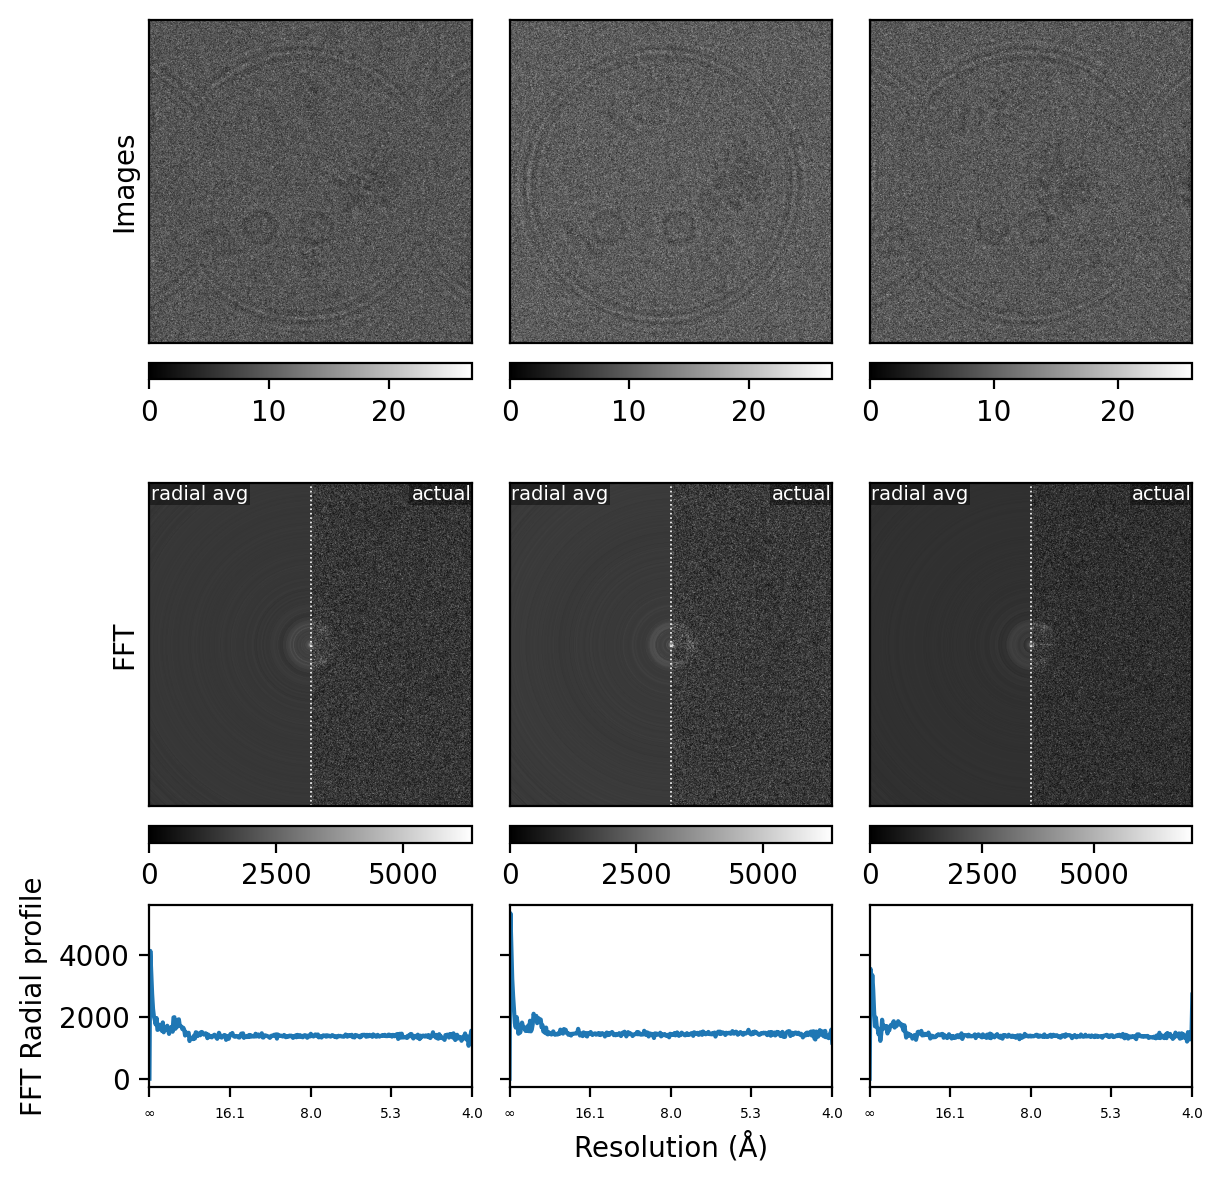

In [13]:
plot_particle_stack(tilt_series, config.target_v_size)